In [ ]:
# ----------------------------------------------------------------------------------------------------------------
# This file contains the code supplementary to the paper:
# Robust Moment-Based Estimation via Spectral Gradient Reweighting

# Copyright (c) 2026 Liu Zhang

# SPDX-License-Identifier: GPL-3.0-only

# This program is free software: you can redistribute it and/or modify it under the terms of 
# the GNU General Public License as published by the Free Software Foundation, version 3.

# This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; 
# without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
# See the GNU General Public License for more details.

# You should have received a copy of the GNU General Public License along with this program. 
# If not, see <https://www.gnu.org/licenses/>. 

# Author: Liu Zhang (lz1619@princeton.edu), Program in Applied and Computational Mathematics, Princeton University
# Last update date: 2026-05-25
# ----------------------------------------------------------------------------------------------------------------

# Numerical Experiments for Robust Diagonally-weighted Generalized Method of Moments ($\verb+RobustDGMM+$) Algorithm

This notebook provides the numerical experiments in Section 5.2 of [1] to validate the **robust diagonally-weighted generalized method of moments ($\verb+RobustDGMM+$)** algorithm, which is a specialization of the main robust $\verb+SGR-GMM+$ algorithm to DGMM [2]. The goal is to estimate heteroscedastic low-rank Gaussian mixtures observed under additive Gaussian noise and adversarial $\varepsilon$-contamination.

[1] Liu Zhang, Amit Singer. Robust Moment-Based Estimation via Spectral Gradient Reweighting. 

[2] Liu Zhang, Oscar Mickelin, Sheng Xu, and Amit Singer. Diagonally-weighted generalized method of moments estimation for Gaussian mixture modeling. arXiv preprint arXiv:2507.20459, 2025.

## Overview of nummerical experiments

| Group | Description | 
|-------|-------------|
| **A** | Convergence and diagnostics | 
| **B** | Statistical validation (multiple trials) | 
| **C** | Comparison with baselines | 

General notes on reproducibility: 
* All data are saved under the folder ```tests/test_data```. 
* All plots are saved under the folder ```figures/```.
* To ensure reproducibility as much as possible, all random functions use a fixed seed number. However, non-zero run-to-run variabilities might still occur. This is due to multi-threaded BLAS/LAPACK functions like ```np.linalg.cholesky```, ```np.linalg.solve```. These run-to-run variabilities do not affect the general conclusions. To minimize such run-to-run variabilities, each simulation has been run multiple times to ensure that the results are consistent across multiple runs. 
* When the code is run on a different device, the actual estimation results might differ slightly from the ones in this notebook. These device-to-device variabilities do not affect the general conclusions. To minimize such device-to-device variabilities, it is recommended to set up a virtual environment and use the pinned versions for the dependencies listed below (especially for ```numpy``` and ```scipy``` since they tend to have more frequent release of substantial updates.) See ```README.rst``` file for installation instructions.
    * ```python==3.11.11```
    * ```numpy==1.26.4```
    * ```scipy==1.15.3```
    * ```scikit-learn==1.7.0```
    * ```sympy==1.14.0```
    * ```matplotlib==3.7.2```
    * ```seaborn==0.12.2```
* If the scripts are run with a different version of Python or other packages, small numerical variabilities might occur. These variabilities do not affect the general conclusions.

In [ ]:
# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------
from gmm import GMM
from robust_dgmm import RobustDGMM
from gm_moments import GaussianMixtureMoments
from robust_gradient_reweighting import RobustGradientReweighting

from utils import (
    params_to_theta,
    compute_average_error,
    compute_average_error_no_permutation,
    theta_to_params,
    generate_ground_truth,
    generate_initial_parameters,
    plot_comparison_figure,
    additive_noise,
    huber_epsilon_contamination,
)
from NystromApprox import compute_moment_sums, compute_exact_moment_sums

from sklearn.mixture import GaussianMixture as SklearnGMM

import os, sys, random, time, warnings
from pathlib import Path
from typing import Iterable
from dataclasses import dataclass, field, replace

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.io import loadmat, savemat
current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)

In [2]:
# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED = 4142
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

In [3]:
# ---------------------------------------------------------------------------
# Matplotlib configuration (publication-quality, LaTeX rendering)
# ---------------------------------------------------------------------------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.formatter.use_mathtext": True,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.unicode_minus": False,
})

In [4]:
# ---------------------------------------------------------------------------
# Run-mode configuration (FAST / MEDIUM / FULL)
# ---------------------------------------------------------------------------
# Set RUN_MODE via environment variable or change here directly.
# FAST   = 3 seeds, reduced grids   (minutes)
# MEDIUM = 8 seeds, moderate grids   (tens of minutes)
# FULL   = 20 seeds, full grids      (hours)
RUN_MODE = os.environ.get("ROBUST_DGMM_RUN_MODE", "FAST").upper()

if RUN_MODE == "FAST":
    N_REPEATS = 3
    N_REPEATS_STAT = 5
elif RUN_MODE == "MEDIUM":
    N_REPEATS = 8
    N_REPEATS_STAT = 15
else:  # FULL
    N_REPEATS = 20
    N_REPEATS_STAT = 30

seed_grid = [SEED + 101 * j for j in range(N_REPEATS)]
stat_seed_grid = [SEED + 101 * j for j in range(N_REPEATS_STAT)]

print(f"RUN_MODE = {RUN_MODE}  |  N_REPEATS = {N_REPEATS}  |  N_REPEATS_STAT = {N_REPEATS_STAT}")

RUN_MODE = FAST  |  N_REPEATS = 3  |  N_REPEATS_STAT = 5


## Helper Functions

In [26]:
# ---------------------------------------------------------------------------
# TrialConfig dataclass and core utilities
# ---------------------------------------------------------------------------

def covariances_from_V(V):
    """Convert low-rank factors V (n_dim, rank, n_components) to full covariances."""
    n_dim, _, n_components = V.shape
    covariances = np.zeros((n_dim, n_dim, n_components), dtype=np.float64)
    for j in range(n_components):
        covariances[:, :, j] = V[:, :, j] @ V[:, :, j].T
    return covariances


@dataclass
class TrialConfig:
    """Configuration for a single end-to-end Robust DGMM trial."""
    n_dim: int = 5
    n_components: int = 2
    n_points: int = 1000
    rank_min: int = 2
    rank_max_true: int = 2
    rank_max_fit: int = 2
    L: int = 4
    noise_scale: float = 0.20
    eps_true: float = 0.10
    eps_assumed: float = 0.10
    outlier_std: float = 4.0
    outlier_mode: str = "gaussian"          # "gaussian", "directional", "far_cluster", "uniform_box", "nearby_cluster"
    outlier_strength: float = 8.0           # magnitude multiplier for structured outliers
    init_method: str = "kmeans_plusplus"
    step_max: int = 2
    iter_max: int = 100
    reweight_interval: int = 5
    algorithm2_step_max_outer: int = 10
    algorithm2_step_max_inner: int = 200
    algorithm2_target_accuracy: float = 1e-6
    softmax_reparam: bool = True
    softmax_temperature: float = 1.5
    # Ground truth generation control
    w_true_min: float = 1.0
    w_true_max: float = 2.0
    center_radius_min: float = 5.0
    center_radius_max: float = 5.0
    seed: int = 0

In [ ]:
# ---------------------------------------------------------------------------
# Structured outlier contamination
# ---------------------------------------------------------------------------

def contaminate_with_geometry(X_clean, eps_true, mode, rng_local, A_true=None, V_true=None, outlier_strength=8.0, outlier_std=4.0):
    n_dim, n_points = X_clean.shape
    X_contaminated = X_clean.copy()

    # Determine which points to replace (Bernoulli model)
    outlier_mask = rng_local.random(n_points) < eps_true
    n_outliers = int(np.sum(outlier_mask))
    if n_outliers == 0:
        return X_contaminated, outlier_mask

    if mode == "gaussian":
        # Isotropic Gaussian outliers (matches huber_epsilon_contamination)
        effective_std = outlier_std if outlier_std is not None else n_dim
        X_contaminated[:, outlier_mask] = rng_local.normal(0, effective_std, size=(n_dim, n_outliers))

    elif mode == "directional":
        # Outliers along the smallest-eigenvalue direction of the first component's covariance
        cov_0 = V_true[:, :, 0] @ V_true[:, :, 0].T
        eigenvalues, eigenvectors = np.linalg.eigh(cov_0)
        v_min = eigenvectors[:, np.argmin(eigenvalues)]
        v_min /= np.linalg.norm(v_min)
        # Place outliers at mean + strength * v_min + small noise
        center = A_true[:, 0] + outlier_strength * v_min
        X_contaminated[:, outlier_mask] = (
            center[:, None] + rng_local.normal(0, 0.1, size=(n_dim, n_outliers))
        )

    elif mode == "uniform_box":
        # Uniform on a large hypercube [4, 10]^d + small noise
        X_contaminated[:, outlier_mask] = (
            rng_local.uniform(4.0, 10.0, size=(n_dim, n_outliers))
            + rng_local.normal(0, 0.1, size=(n_dim, n_outliers))
        )

    else:
        raise ValueError(f"Unknown outlier mode: {mode}")

    return X_contaminated, outlier_mask

In [ ]:
# ---------------------------------------------------------------------------
# Data generation, model building, fitting, and scoring
# ---------------------------------------------------------------------------

def make_trial_data(cfg: TrialConfig):
    """Generate ground truth, add noise, contaminate, and create initial parameters."""
    np.random.seed(cfg.seed)
    X_clean, pi_true, A_true, V_true, cov_true, ranks_true, w_true, labels_true = generate_ground_truth(
        n_dim=cfg.n_dim,
        n_components=cfg.n_components,
        n_points=cfg.n_points,
        rank_min=cfg.rank_min,
        rank_max=cfg.rank_max_true,
        w_true_min=[cfg.w_true_min] * cfg.n_components,
        w_true_max=[cfg.w_true_max] * cfg.n_components,
        normalization=True,
        center_radius_min=cfg.center_radius_min,
        center_radius_max=cfg.center_radius_max,
    )

    # Additive noise
    noise_covariance = cfg.noise_scale * np.eye(cfg.n_dim)
    X_noisy = additive_noise(X_clean, noise_covariance) if cfg.noise_scale > 0 else X_clean.copy()

    # Contamination
    rng_contam = np.random.default_rng(cfg.seed + 123)
    if cfg.outlier_mode == "gaussian":
        X_observed, outlier_mask = huber_epsilon_contamination(
            X_noisy, cfg.eps_true, rng=rng_contam,
            outlier_std=cfg.outlier_std, return_mask=True,
        )
    else:
        X_observed, outlier_mask = contaminate_with_geometry(
            X_noisy, cfg.eps_true, cfg.outlier_mode, rng_contam,
            A_true=A_true, V_true=V_true,
            outlier_strength=cfg.outlier_strength, outlier_std=cfg.outlier_std,
        )

    # Initial parameters
    pi_init, A_init, V_init, _ = generate_initial_parameters(cfg.n_dim, cfg.rank_max_fit, cfg.n_components, init_method=cfg.init_method, X=X_observed,)
    theta_init = params_to_theta(pi_init, A_init, V_init, cfg.softmax_reparam, cfg.softmax_temperature)

    return {
        "X_clean": X_clean,
        "X_noisy": X_noisy,
        "X_observed": X_observed,
        "noise_covariance": noise_covariance,
        "outlier_mask": outlier_mask,
        "pi_true": pi_true,
        "A_true": A_true,
        "V_true": V_true,
        "cov_true": cov_true,
        "theta_init": theta_init,
        "ranks_true": ranks_true,
    }


def build_model(theta_init, cfg: TrialConfig, mode: str, noise_covariance):
    """
    Create a RobustDGMM model in one of three modes:
      'naive'       — ignores noise and contamination
      'noise_aware' — uses noise covariance but epsilon=0
      'robust'      — full robust DGMM
    """
    common_kwargs = dict(
        theta_init=theta_init,
        rank=cfg.rank_max_fit,
        n_components=cfg.n_components,
        L=cfg.L,
        W_init="diagonal",
        W_step="diagonal",
        step_max=cfg.step_max,
        iter_max=cfg.iter_max,
        reweight_interval=cfg.reweight_interval,
        algorithm2_step_max_outer=cfg.algorithm2_step_max_outer,
        algorithm2_step_max_inner=cfg.algorithm2_step_max_inner,
        algorithm2_target_accuracy=cfg.algorithm2_target_accuracy,
        softmax_reparam=cfg.softmax_reparam,
        softmax_temperature=cfg.softmax_temperature,
    )

    if mode == "naive":
        return RobustDGMM(**common_kwargs, contamination_epsilon=0.0, noise_covariance=None)
    elif mode == "noise_aware":
        return RobustDGMM(**common_kwargs, contamination_epsilon=0.0, noise_covariance=noise_covariance)
    elif mode == "robust":
        return RobustDGMM(**common_kwargs, contamination_epsilon=cfg.eps_assumed, noise_covariance=noise_covariance)
    else:
        raise ValueError(f"Unknown mode: {mode}")


def fit_and_score(model, X, pi_true, A_true, cov_true, outlier_mask=None):
    """Fit the model, extract parameters, and compute average relative errors."""
    t_start = time.perf_counter()
    theta_opt, n_iter = model.fit(X)
    runtime_s = time.perf_counter() - t_start

    pi_est, A_est, V_est = theta_to_params(
        theta_opt, model.n_dim, model.rank, model.n_components,
        model.softmax_reparam, model.softmax_temperature,
    )
    cov_est = covariances_from_V(V_est)
    err_pi, err_mu, err_cov, permutation = compute_average_error(
        pi_est, A_est, cov_est, pi_true, A_true, cov_true,
    )

    result = {
        "err_pi": float(err_pi),
        "err_mu": float(err_mu),
        "err_cov": float(err_cov),
        "runtime_s": float(runtime_s),
        "n_iter": int(n_iter),
        "permutation": permutation,
    }

    # Track outlier mass retained per order (diagnostic only)
    if outlier_mask is not None and hasattr(model, "robust_per_order_weights") and model.robust_per_order_weights is not None:
        outlier_mass_per_order = np.sum(model.robust_per_order_weights[:, outlier_mask], axis=1)
        result["mean_outlier_mass"] = float(np.mean(outlier_mass_per_order))
        result["max_outlier_mass"] = float(np.max(outlier_mass_per_order))
    else:
        result["mean_outlier_mass"] = float("nan")
        result["max_outlier_mass"] = float("nan")

    return result, model


def run_modes(cfg: TrialConfig, modes=None):
    """Run naive, noise_aware, and robust modes on the same data and return a results DataFrame."""
    if modes is None:
        modes = [("Naive DGMM", "naive"), ("Noise-aware DGMM", "noise_aware"), ("RobustDGMM", "robust")]
    data = make_trial_data(cfg)
    rows = []
    models = {}
    for label, mode in modes:
        model = build_model(data["theta_init"], cfg, mode, data["noise_covariance"])
        result, fitted_model = fit_and_score(
            model, data["X_observed"], data["pi_true"], data["A_true"], data["cov_true"],
            outlier_mask=data["outlier_mask"],
        )
        result["method"] = label
        result["mode"] = mode
        rows.append(result)
        models[mode] = fitted_model
    return pd.DataFrame(rows), data, models

In [ ]:
# ---------------------------------------------------------------------------
# Plotting helpers
# ---------------------------------------------------------------------------

def plot_mean_with_band(ax, x, y_mean, y_std, label, marker="o"):
    """Plot a line with a shaded +/- 1 std band."""
    line = ax.plot(x, y_mean, marker=marker, label=label, markersize=4)[0]
    ax.fill_between(x, y_mean - y_std, y_mean + y_std, color=line.get_color(), alpha=0.10, linewidth=0.0)


def summarise_metric(df, group_cols, metric_cols):
    """Compute mean and std of metric columns grouped by group_cols."""
    agg_dict = {}
    for col in metric_cols:
        agg_dict[col + "_mean"] = (col, "mean")
        agg_dict[col + "_std"] = (col, "std")
        agg_dict[col + "_median"] = (col, "median")
    return df.groupby(group_cols, sort=False).agg(**agg_dict).reset_index()


def run_repeated_trials(base_cfg, seeds, modes=None):
    """Run trials across multiple seeds, collecting all results in a DataFrame."""
    all_rows = []
    for s in seeds:
        cfg = replace(base_cfg, seed=s)
        try:
            df, _, _ = run_modes(cfg, modes=modes)
            df["seed"] = s
            all_rows.append(df)
        except Exception as e:
            warnings.warn(f"Trial seed={s} failed: {e}")
    if not all_rows:
        return pd.DataFrame()
    return pd.concat(all_rows, ignore_index=True)


def run_sweep(base_cfg, param_name, param_values, seeds, modes=None, extra_cols=None):
    """Run a parameter sweep across multiple seeds, returning a DataFrame."""
    all_rows = []
    for pval in param_values:
        cfg = replace(base_cfg, **{param_name: pval})
        for s in seeds:
            cfg_s = replace(cfg, seed=s)
            try:
                df, _, _ = run_modes(cfg_s, modes=modes)
                df["seed"] = s
                df[param_name] = pval
                if extra_cols:
                    for k, v in extra_cols.items():
                        df[k] = v
                all_rows.append(df)
            except Exception as e:
                warnings.warn(f"Sweep {param_name}={pval}, seed={s} failed: {e}")
    if not all_rows:
        return pd.DataFrame()
    return pd.concat(all_rows, ignore_index=True)


FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_pdf(fig, name):
    """Save figure as PDF."""
    path = FIG_DIR / name
    fig.savefig(path, format="pdf", bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)
    print(f"Saved: {path}")

In [ ]:
# ---------------------------------------------------------------------------
# Additional diagnostics helpers for the updated notebook
# ---------------------------------------------------------------------------

PARAMETER_ERROR_LABELS = {
    "err_pi": r"Average relative mixing-weight error",
    "err_mu": r"Average relative center error",
    "err_cov": r"Average relative covariance error",
}

METHOD_DISPLAY_ORDER = ["Naive DGMM", "Noise-aware DGMM", "RobustDGMM", "sklearn EM"]


def compute_parameter_errors_from_theta(theta, n_dim, rank, n_components, softmax_reparam, softmax_temperature, pi_true, A_true, cov_true):
    """Compute parameter errors from a parameter vector."""
    pi_est, A_est, V_est = theta_to_params(theta, n_dim, rank, n_components, softmax_reparam, softmax_temperature,)
    cov_est = covariances_from_V(V_est)
    return compute_average_error(pi_est, A_est, cov_est, pi_true, A_true, cov_true)


def compute_error_history_from_model(model, data_dict):
    """Evaluate (err_pi, err_mu, err_cov) along ``model.robust_theta_history``."""
    rows = []
    theta_history = getattr(model, "robust_theta_history", None)
    if theta_history is None:
        return pd.DataFrame(columns=["history_index", "err_pi", "err_mu", "err_cov"])

    for idx, theta in enumerate(theta_history):
        err_pi, err_mu, err_cov, _ = compute_parameter_errors_from_theta(
            theta=theta,
            n_dim=model.n_dim,
            rank=model.rank,
            n_components=model.n_components,
            softmax_reparam=model.softmax_reparam,
            softmax_temperature=model.softmax_temperature,
            pi_true=data_dict["pi_true"],
            A_true=data_dict["A_true"],
            cov_true=data_dict["cov_true"],
        )
        rows.append({
            "history_index": idx,
            "err_pi": float(err_pi),
            "err_mu": float(err_mu),
            "err_cov": float(err_cov),
        })
    return pd.DataFrame(rows)


def extract_per_order_outlier_mass_history(model, outlier_mask):
    """Return a long-form DataFrame of per-order outlier mass across stored reweightings."""
    rows = []
    history = getattr(model, "robust_per_order_weights_history", None)
    stage_names = getattr(model, "robust_reweight_stage_history", None)

    if history is not None and len(history) > 0:
        for stage_idx, weights in enumerate(history):
            stage_name = stage_names[stage_idx] if stage_names is not None and stage_idx < len(stage_names) else f"stage_{stage_idx}"
            weights = np.asarray(weights, dtype=np.float64)
            for order_idx in range(weights.shape[0]):
                rows.append({
                    "stage_index": stage_idx,
                    "stage_name": stage_name,
                    "order": order_idx + 1,
                    "outlier_mass": float(np.sum(weights[order_idx, outlier_mask])),
                })
        return pd.DataFrame(rows)

    # Fallback for older class versions without explicit per-order-weight history.
    reweighter_history = getattr(model, "robust_reweighter_history", None)
    if reweighter_history is None:
        return pd.DataFrame(columns=["stage_index", "stage_name", "order", "outlier_mass"])

    stage_idx = 0
    for entry in reweighter_history:
        if isinstance(entry, list):
            for order_idx, rw in enumerate(entry):
                weights = getattr(rw, "sample_weights", None)
                if weights is None:
                    continue
                rows.append({
                    "stage_index": stage_idx,
                    "stage_name": f"stage_{stage_idx}",
                    "order": order_idx + 1,
                    "outlier_mass": float(np.sum(np.asarray(weights)[outlier_mask])),
                })
            stage_idx += 1

    return pd.DataFrame(rows)


def style_parameter_error_axis(ax, metric_key):
    ax.set_ylabel(PARAMETER_ERROR_LABELS[metric_key])


def robust_section_cfg(base_cfg: TrialConfig, **kwargs):
    """Return a mildly stronger configuration for challenging robust-DGMM sections."""
    return replace(
        base_cfg,
        step_max=max(base_cfg.step_max, kwargs.pop("step_max", 3)),
        iter_max=max(base_cfg.iter_max, kwargs.pop("iter_max", 80)),
        reweight_interval=kwargs.pop("reweight_interval", 10),
        algorithm2_step_max_outer=max(base_cfg.algorithm2_step_max_outer, kwargs.pop("algorithm2_step_max_outer", 12)),
        algorithm2_step_max_inner=max(base_cfg.algorithm2_step_max_inner, kwargs.pop("algorithm2_step_max_inner", 200)),
        **kwargs,
    )

In [ ]:
# ---------------------------------------------------------------------------
# Baseline comparison helpers
# ---------------------------------------------------------------------------

def fit_sklearn_gmm(X, n_dim, n_components, rank_max, rank_min, pi_true, A_true, cov_true, pi_init, A_init, cov_init):

    from sklearn.mixture import GaussianMixture as SklearnGMM

    n_dim, n_components = A_init.shape
    n_dim, n_points = X.shape
    
    
    precisions_init = np.zeros((n_components, n_dim, n_dim))
    
    if rank_min < n_dim:
        epsilon = 1e-10
        
        for j in range(n_components):
            
            eigvals, eigvecs = scipy.linalg.eigh(cov_init[:,:,j])
            eigvals[:] += epsilon
            
            precisions_init[j, :, :] = eigvecs @ np.diag(1.0 / eigvals) @ eigvecs.T
            
        
    else:
        for j in range(n_components):
            precisions_init[j, :, :] = np.linalg.inv(cov_init[:, :, j])
    
    t0 = time.perf_counter()
    gmm = SklearnGMM(n_components = n_components, 
                 weights_init = pi_init[0, :], 
                 means_init = A_init.T, 
                 precisions_init = precisions_init, 
                 covariance_type="full",
                 max_iter=300,
                 n_init=1, 
                 random_state=SEED,).fit(X.T)
    
    runtime_s = time.perf_counter() - t0
    
    pi_est = gmm.weights_.reshape((1,n_components))
    A_est = gmm.means_.T
    cov_est = gmm.covariances_.transpose((1,2,0))

    err_pi, err_mu, err_cov, _ = compute_average_error(pi_est, A_est, cov_est, pi_true, A_true, cov_true)
    
    return {
        "err_pi": float(err_pi),
        "err_mu": float(err_mu),
        "err_cov": float(err_cov),
        "runtime_s": float(runtime_s),
        "method": "sklearn EM",
    }


def compute_sample_baseline(X_observed, pi_true, A_true, cov_true, n_components):
    """Compute naive sample mean and covariance as a baseline (for K=1 or as overall statistics)."""
    n_dim, n_points = X_observed.shape
    mu_sample = np.mean(X_observed, axis=1)           # (d,)
    cov_sample = np.cov(X_observed)                   # (d, d)

    # For K components, assign all data to component 0 as a crude baseline
    pi_est = np.ones((1, n_components)) / n_components
    A_est = np.tile(mu_sample[:, None], (1, n_components))
    cov_est_full = np.zeros((n_dim, n_dim, n_components))
    for j in range(n_components):
        cov_est_full[:, :, j] = cov_sample

    err_pi, err_mu, err_cov, _ = compute_average_error(pi_est, A_est, cov_est_full, pi_true, A_true, cov_true)
    return {
        "err_pi": float(err_pi),
        "err_mu": float(err_mu),
        "err_cov": float(err_cov),
        "runtime_s": 0.0,
        "method": "Sample baseline",
    }

In [38]:
import os
from pathlib import Path

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_pdf(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, format="pdf", bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)
    print(f"saved: {path}")

---

## Group A: Convergence and Diagnostics

These experiments examine the convergence behaviour of $\verb+RobustDGMM+$. We track the robust objective function values $Q_{\tilde{\delta}}^{(\ell)}(\theta)$, parameter changes $\|\theta^{(\ell+1)} - \theta^{(\ell)}\|$, weight changes $\|w^{[s+1]} - w^{[s]}\|_1$, and the spectral norm $\|S(w; \{\bar{g}_n\}, \tilde{\mu}^{[s]})\|_{\mathrm{op}}$ across iterations.

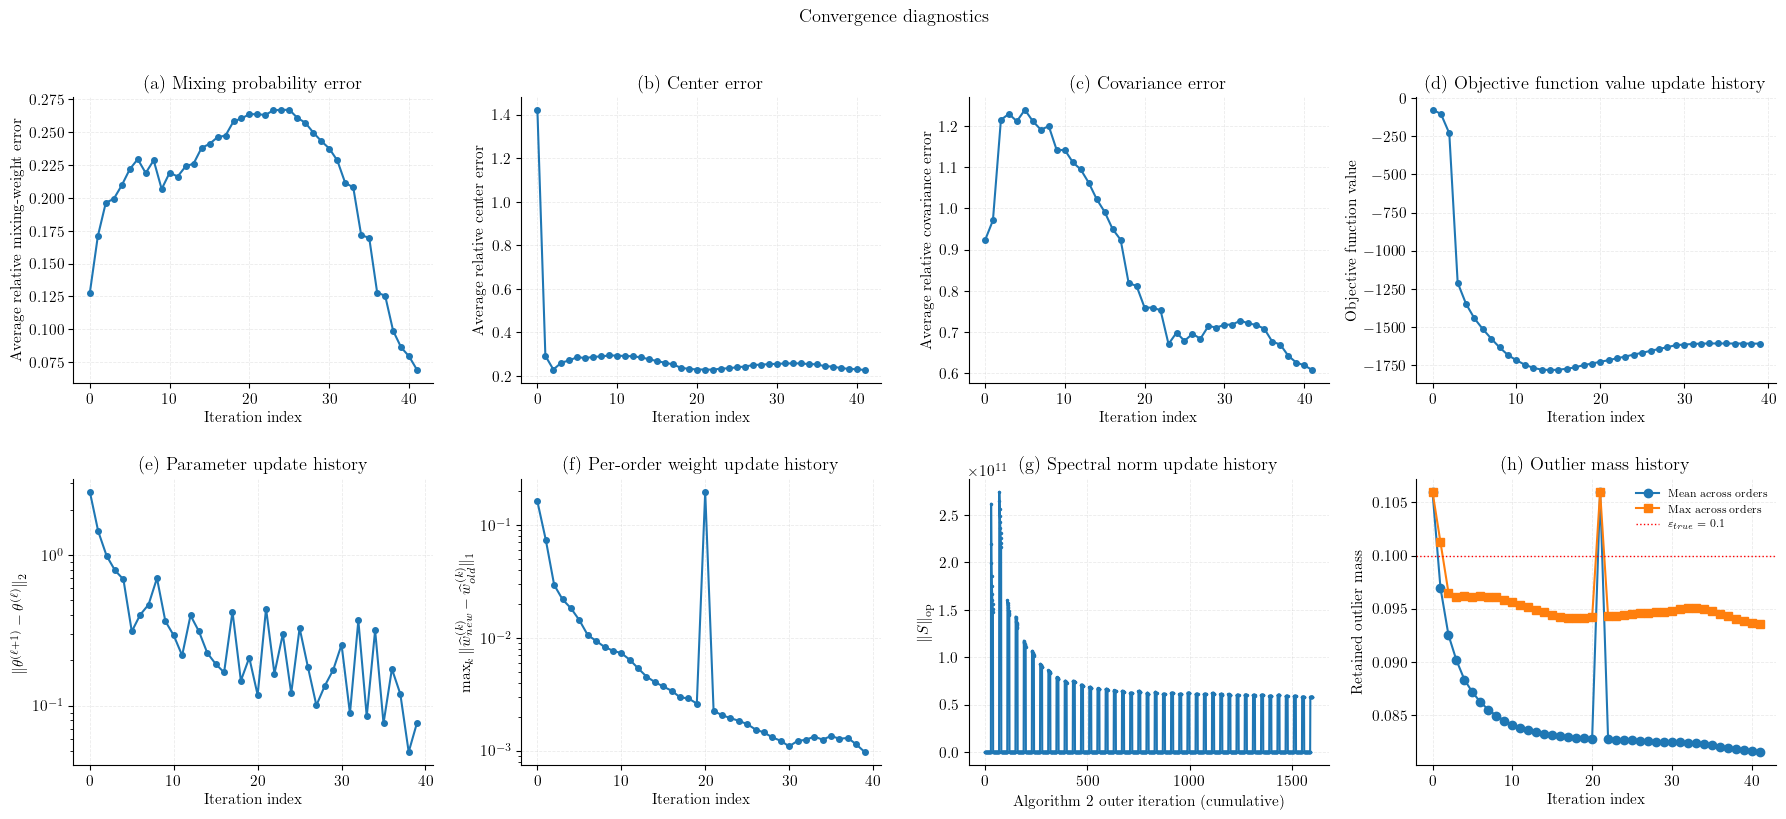

In [30]:
# ---------------------------------------------------------------------------
# A1: Convergence history (single representative fit)
# ---------------------------------------------------------------------------
a1_cfg = TrialConfig(
    n_dim=5, n_components=2, n_points=1000, rank_min=2, rank_max_true=2, rank_max_fit=2,
    L=4, noise_scale=0.20, eps_true=0.10, eps_assumed=0.10, outlier_std=4.0,
    step_max=2, iter_max=100, softmax_reparam=True, softmax_temperature=1.5,
    reweight_interval=5, algorithm2_step_max_outer=10, algorithm2_step_max_inner=200,
    seed=SEED,
)
a1_data = make_trial_data(a1_cfg)
a1_model = build_model(a1_data["theta_init"], a1_cfg, "robust", a1_data["noise_covariance"])
a1_result, a1_model = fit_and_score(
    a1_model, a1_data["X_observed"], a1_data["pi_true"], a1_data["A_true"], a1_data["cov_true"],
    outlier_mask=a1_data["outlier_mask"],
)

a1_error_history = compute_error_history_from_model(a1_model, a1_data)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# (a)-(c) DGMM Section-5 parameter errors along the theta history
if not a1_error_history.empty:
    axes[0, 0].plot(a1_error_history["history_index"], a1_error_history["err_pi"], marker="o", markersize=4)
    axes[0, 1].plot(a1_error_history["history_index"], a1_error_history["err_mu"], marker="o", markersize=4)
    axes[0, 2].plot(a1_error_history["history_index"], a1_error_history["err_cov"], marker="o", markersize=4)

axes[0, 0].set_title("(a) Mixing probability error")
axes[0, 0].set_xlabel("Iteration index")
axes[0, 0].set_ylabel(PARAMETER_ERROR_LABELS["err_pi"])

axes[0, 1].set_title("(b) Center error")
axes[0, 1].set_xlabel("Iteration index")
axes[0, 1].set_ylabel(PARAMETER_ERROR_LABELS["err_mu"])

axes[0, 2].set_title("(c) Covariance error")
axes[0, 2].set_xlabel("Iteration index")
axes[0, 2].set_ylabel(PARAMETER_ERROR_LABELS["err_cov"])

# (d) Objective history
axes[0, 3].plot(a1_model.robust_objective_history, marker="o", markersize=4)
axes[0, 3].set_xlabel("Iteration index")
axes[0, 3].set_ylabel("Objective function value")
axes[0, 3].set_title("(d) Objective function value update history")

# (e) Parameter change
axes[1, 0].plot(a1_model.robust_theta_change_history, marker="o", markersize=4)
axes[1, 0].set_xlabel("Iteration index")
axes[1, 0].set_ylabel(r"$\|\theta^{(\ell+1)} - \theta^{(\ell)}\|_2$")
axes[1, 0].set_title("(e) Parameter update history")
axes[1, 0].set_yscale("log")

# (f) Weight change
if a1_model.robust_weight_change_history:
    axes[1, 1].plot(a1_model.robust_weight_change_history, marker="o", markersize=4)
axes[1, 1].set_xlabel("Iteration index")
axes[1, 1].set_ylabel(r"$\max_k\|\widehat w^{(k)}_{new} - \widehat w^{(k)}_{old}\|_1$")
axes[1, 1].set_title("(f) Per-order weight update history")
axes[1, 1].set_yscale("log")

# (g) Spectral norm history from Algorithm 2
spectral_norms_all = []
if a1_model.robust_reweighter_history:
    for entry in a1_model.robust_reweighter_history:
        if isinstance(entry, list):
            for rw in entry:
                if hasattr(rw, "spectral_norm_history"):
                    spectral_norms_all.extend(rw.spectral_norm_history)
        elif hasattr(entry, "spectral_norm_history"):
            spectral_norms_all.extend(entry.spectral_norm_history)
if spectral_norms_all:
    axes[1, 2].plot(spectral_norms_all, marker=".", markersize=3)
axes[1, 2].set_xlabel("Algorithm 2 outer iteration (cumulative)")
axes[1, 2].set_ylabel(r"$\|S\|_{\mathrm{op}}$")
axes[1, 2].set_title("(g) Spectral norm update history")

# (h) Mean retained outlier mass across stored per-order weights
a1_outlier_history = extract_per_order_outlier_mass_history(a1_model, a1_data["outlier_mask"])
if not a1_outlier_history.empty:
    summary_outlier = a1_outlier_history.groupby("stage_index").agg(
        mean_outlier_mass=("outlier_mass", "mean"),
        max_outlier_mass=("outlier_mass", "max"),
    ).reset_index()
    axes[1, 3].plot(summary_outlier["stage_index"], summary_outlier["mean_outlier_mass"],
                    marker="o", label="Mean across orders")
    axes[1, 3].plot(summary_outlier["stage_index"], summary_outlier["max_outlier_mass"],
                    marker="s", label="Max across orders")
axes[1, 3].axhline(a1_cfg.eps_true, color="red", linestyle=":", linewidth=1.0,
                   label=rf"$\varepsilon_{{true}}={a1_cfg.eps_true}$")
axes[1, 3].set_xlabel("Iteration index")
axes[1, 3].set_ylabel("Retained outlier mass")
axes[1, 3].set_title("(h) Outlier mass history")
axes[1, 3].legend(fontsize=8)
        
fig.suptitle("Convergence diagnostics", y=1.02)
fig.tight_layout()
plt.show()

In [44]:
savemat(os.path.join(parent_directory,  'tests/test_data', 'a1_data.mat'), a1_data) 
a1_error_history.to_csv(os.path.join(parent_directory,  'tests/test_data', 'a1_error_history.csv'), index=True) 
a1_outlier_history.to_csv(os.path.join(parent_directory,  'tests/test_data', 'a1_outlier_history.csv'), index=True)
save_pdf(fig, "fig_convergence_diagnostics.pdf")

saved: figures/fig_convergence_diagnostics.pdf


---

## Group B: Statistical Validation (Multiple Seeds)

These experiments use a large number of independent seeds ($N_{\mathrm{REPEATS\_STAT}}$) to
characterize the distribution of estimation errors across random realizations of the data,
contamination, and initialization. This provides confidence intervals and tests whether the
the advantage of $\verb+RobustDGMM+$ is statistically significant.

In [45]:
# ---------------------------------------------------------------------------
# B1: Repeated trials for 4 key configurations
# ---------------------------------------------------------------------------
b1_configs = {
    "Clean": replace(TrialConfig(seed=0), noise_scale=0.0, eps_true=0.0, eps_assumed=0.0),
    "Noise only": replace(TrialConfig(seed=0), noise_scale=0.20, eps_true=0.0, eps_assumed=0.0),
    "Contamination only": replace(TrialConfig(seed=0), noise_scale=0.0, eps_true=0.10, eps_assumed=0.10),
    "Both": replace(TrialConfig(seed=0), noise_scale=0.20, eps_true=0.10, eps_assumed=0.10),
}

b1_all = []
for label, cfg in b1_configs.items():
    df = run_repeated_trials(cfg, stat_seed_grid)
    df["config"] = label
    b1_all.append(df)
b1_df = pd.concat(b1_all, ignore_index=True)

# Summary table
b1_summary = b1_df.groupby(["config", "method"]).agg(
    err_pi_mean=("err_pi", "mean"), err_pi_std=("err_pi", "std"),
    err_mu_mean=("err_mu", "mean"), err_mu_std=("err_mu", "std"),
    err_cov_mean=("err_cov", "mean"), err_cov_std=("err_cov", "std"),
    runtime_mean=("runtime_s", "mean"),
).reset_index()
print("B1: Summary statistics")
b1_summary

B1: Summary statistics


,config,method,err_pi_mean,err_pi_std,err_mu_mean,err_mu_std,err_cov_mean,err_cov_std,runtime_mean
0,Both,Naive DGMM,1.687308,1.648177,1.704079,0.730592,25.719702,23.690259,0.401185
1,Both,Noise-aware DGMM,1.402508,1.716189,1.622599,0.912302,27.490586,30.497567,1.253636
2,Both,RobustDGMM,0.226619,0.295889,0.465811,0.249497,2.177167,0.750899,388.968583
3,Clean,Naive DGMM,0.069885,0.065303,0.047776,0.036162,0.198338,0.134030,0.413457
4,Clean,Noise-aware DGMM,0.069885,0.065303,0.047776,0.036162,0.198338,0.134030,0.421000
5,Clean,RobustDGMM,0.069885,0.065303,0.047776,0.036162,0.198338,0.134030,0.408343
6,Contamination only,Naive DGMM,1.154906,1.828217,1.517911,1.020011,38.457284,45.599675,0.385756
7,Contamination only,Noise-aware DGMM,1.154906,1.828217,1.517911,1.020011,38.457284,45.599675,0.385914
8,Contamination only,RobustDGMM,0.067575,0.056400,0.523574,0.228449,2.458773,0.884887,392.628207
9,Noise only,Naive DGMM,0.352071,0.425875,0.205168,0.115748,0.991184,0.730812,0.427669


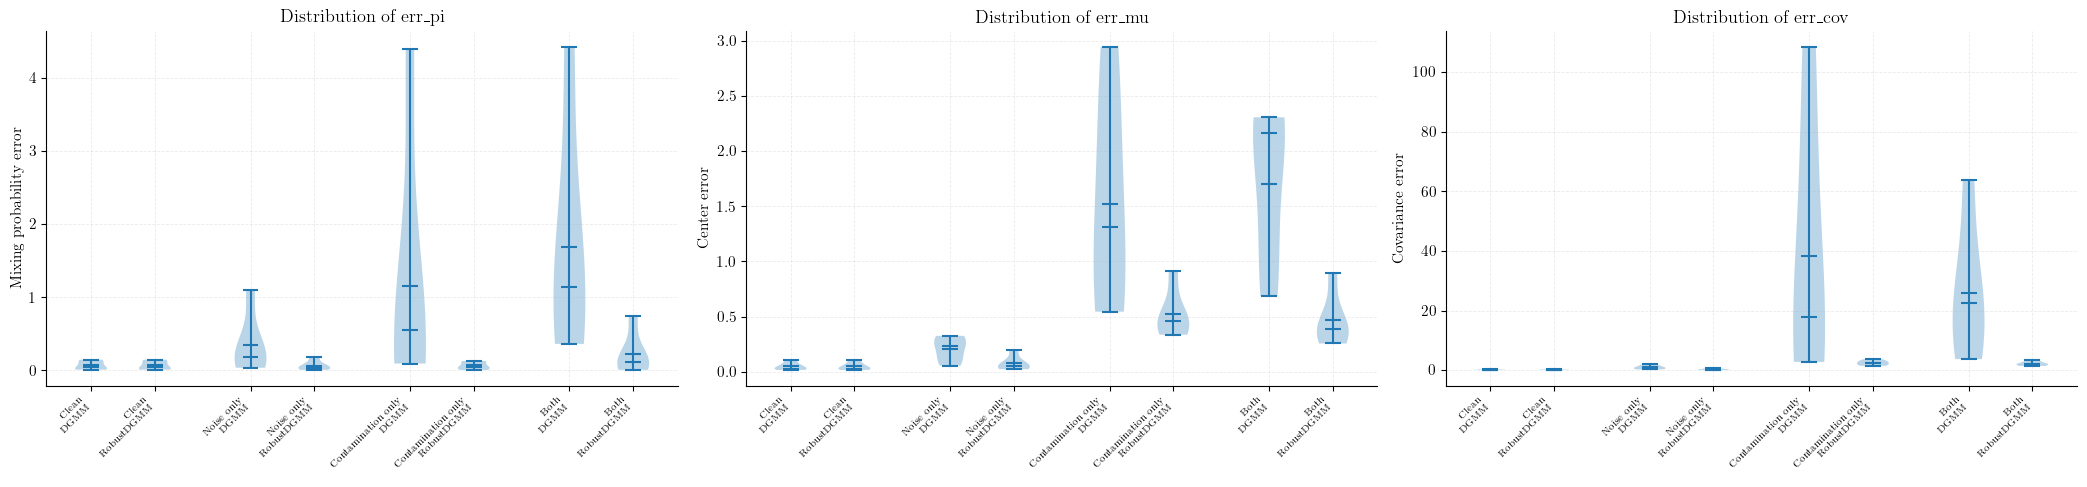

In [47]:
# ---------------------------------------------------------------------------
# Violin / box plots
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Mean error violin plot
for i, metric in enumerate(["err_pi", "err_mu", "err_cov"]):
    ax = axes[i]
    configs = list(b1_configs.keys())
    methods = ["Naive DGMM", "RobustDGMM"]
    positions = []
    labels_plot = []
    data_violin = []
    pos = 0
    for cfg_label in configs:
        for m in methods:
            sub = b1_df[(b1_df["config"] == cfg_label) & (b1_df["method"] == m)]
            data_violin.append(sub[metric].values)
            positions.append(pos)
            labels_plot.append(f"{cfg_label}\n{m.split()[-1]}")
            pos += 1
        pos += 0.5  # gap between configs

    vp = ax.violinplot(data_violin, positions=positions, showmeans=True, showmedians=True)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels_plot, fontsize=7, rotation=45, ha="right")
    ylabel = r"Center error" if metric == "err_mu" else r"Covariance error" if metric == "err_cov" else r"Mixing probability error"
    ax.set_ylabel(ylabel)
    ax.set_title(f"Distribution of {metric}")

fig.tight_layout(); plt.show()

In [50]:
b1_df.to_csv(os.path.join(parent_directory,  'tests/test_data', 'b1_df.csv'), index=True) 
b1_summary.to_csv(os.path.join(parent_directory,  'tests/test_data', 'b1_summary.csv'), index=True) 
save_pdf(fig, "fig_repeated_trials.pdf")

saved: figures/fig_repeated_trials.pdf


---

## Group C: Comparison with Baselines

These experiments compare $\verb+RobustDGMM+$ against standard baselines:

1. **$\verb+Naive DGMM+$** — baseline DGMM ignoring both noise and contamination.
2. **$\verb+Noise-aware DGMM+$** — baseline DGMM using the noise covariance but ignoring contamination.
3. **$\verb+sklearn EM+$** — the standard Expectation-Maximization algorithm (`sklearn.mixture.GaussianMixture`).

In [ ]:
# ---------------------------------------------------------------------------
# C1: Four-way comparison across outlier geometries (fairer stress test)
# ---------------------------------------------------------------------------
geometry_values_c1 = ["gaussian", "directional", "far_cluster", "uniform_box"]
base_cfg_c1 = TrialConfig(
    n_dim=5, n_components=2, n_points=1000, rank_min=2, rank_max_true=2, rank_max_fit=2,
    L=4, noise_scale=0.20, eps_true=0.10, eps_assumed=0.10, outlier_std=4.0,
    step_max=2, iter_max=100, softmax_reparam=True, softmax_temperature=1.5,
    reweight_interval=5, algorithm2_step_max_outer=10, algorithm2_step_max_inner=200,
)

c1_rows = []
for geom in geometry_values_c1:
    cfg = replace(base_cfg_c1, outlier_mode=geom, outlier_strength=8.0)
    for s in seed_grid:
        cfg_s = replace(cfg, seed=s)
        data = make_trial_data(cfg_s)

        for label, mode in [("Naive DGMM", "naive"), ("Noise-aware DGMM", "noise_aware"), ("RobustDGMM", "robust")]:
            model = build_model(data["theta_init"], cfg_s, mode, data["noise_covariance"])
            result, _ = fit_and_score(
                model, data["X_observed"], data["pi_true"], data["A_true"], data["cov_true"],
                outlier_mask=data["outlier_mask"],
            )
            result["method"] = label
            result["geometry"] = geom
            result["seed"] = s
            c1_rows.append(result)

        try:
            pi_init, A_init, V_init = theta_to_params(data["theta_init"], cfg_s.n_dim, cfg_s.rank_max_fit, cfg_s.n_components, cfg_s.softmax_reparam, cfg_s.softmax_temperature)
            cov_init = np.zeros((cfg_s.n_dim, cfg_s.n_dim, cfg_s.n_components))
            for j in range(cfg_s.n_components):
                cov_init[:, :, j] = V_init[:, :, j] @ V_init[:, :, j].T
            em_result = fit_sklearn_gmm(data["X_observed"], cfg_s.n_dim, cfg_s.n_components, cfg_s.rank_max_fit, cfg_s.rank_min, data["pi_true"], data["A_true"], data["cov_true"], pi_init, A_init, cov_init)
            
            em_result["geometry"] = geom
            em_result["seed"] = s
            c1_rows.append(em_result)
        except Exception as e:
            warnings.warn(f"sklearn EM failed for geometry={geom}, seed={s}: {e}")

c1_df = pd.DataFrame(c1_rows)

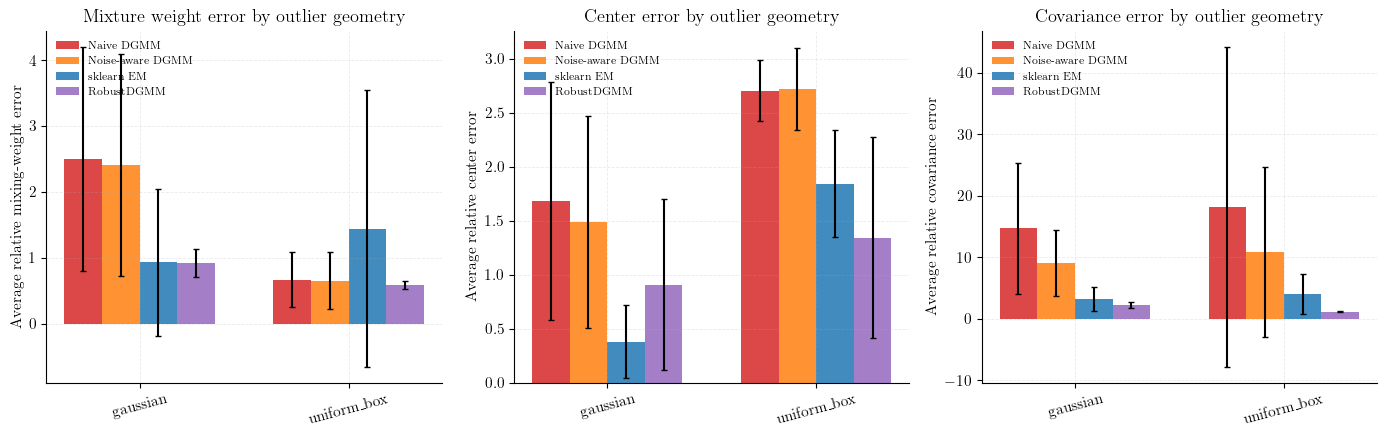

In [ ]:
METHOD_DISPLAY_ORDER = ["Naive DGMM", "Noise-aware DGMM", "sklearn EM", "RobustDGMM"]
geometry_values_c1 = ["gaussian", "uniform_box"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
x_pos = np.arange(len(geometry_values_c1))
width = 0.18

c1_summary = c1_df.groupby(["geometry", "method"]).agg(
    err_pi_mean=("err_pi", "mean"), err_pi_std=("err_pi", "std"),
    err_mu_mean=("err_mu", "mean"), err_mu_std=("err_mu", "std"),
    err_cov_mean=("err_cov", "mean"), err_cov_std=("err_cov", "std"),
).reset_index()

colors = ["#d62728", "#ff7f0e", "#1f77b4", "#9467bd"]

for i, method in enumerate(METHOD_DISPLAY_ORDER):
    sub = c1_summary[c1_summary["method"] == method].set_index("geometry").reindex(geometry_values_c1).reset_index()
    axes[0].bar(
        x_pos + i * width,
        sub["err_pi_mean"],
        width,
        yerr=sub["err_pi_std"],
        alpha=0.85,
        label=method,
        capsize=2,
        color=colors[i],
    )
    axes[1].bar(
        x_pos + i * width,
        sub["err_mu_mean"],
        width,
        yerr=sub["err_mu_std"],
        alpha=0.85,
        label=method,
        capsize=2,
        color=colors[i],
    )
    axes[2].bar(
        x_pos + i * width,
        sub["err_cov_mean"],
        width,
        yerr=sub["err_cov_std"],
        alpha=0.85,
        label=method,
        capsize=2,
        color=colors[i],
    )

for ax in axes:
    ax.set_xticks(x_pos + 1.5 * width)
    ax.set_xticklabels(geometry_values_c1, rotation=15)

axes[0].set_ylabel(PARAMETER_ERROR_LABELS["err_pi"])
axes[0].set_title("Mixture weight error by outlier geometry")
axes[0].legend(loc="upper left", fontsize=8)

axes[1].set_ylabel(PARAMETER_ERROR_LABELS["err_mu"])
axes[1].set_title("Center error by outlier geometry")
axes[1].legend(loc="upper left", fontsize=8)

axes[2].set_ylabel(PARAMETER_ERROR_LABELS["err_cov"])
axes[2].set_title("Covariance error by outlier geometry")
axes[2].legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()

In [77]:
c1_df.to_csv(os.path.join(parent_directory,  'tests/test_data', 'c1_df.csv'), index=True) 
c1_summary.to_csv(os.path.join(parent_directory,  'tests/test_data', 'c1_summary.csv'), index=True) 
save_pdf(fig, "fig_comparison.pdf")

saved: figures/fig_comparison.pdf
